# Análisis de Big Data sobre Seguros y Siniestros en el Perú (2001-2024)

## 1. Configuración del Entorno y Carga de Datos

Configuramos la sesión Spark de forma silenciosa para producción y cargamos el archivo CSV de forma local.

In [1]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

# Forzar el uso del Java 21 instalado localmente en el entorno dl de Anaconda
os.environ["JAVA_HOME"] = r"C:\Users\Marcelo\anaconda3\envs\dl\Library"
os.environ["PATH"] = r"C:\Users\Marcelo\anaconda3\envs\dl\Library\bin;" + os.environ["PATH"]

# Configurar argumentos de Java para PySpark en Java 17/21
jvm_opts = (
    "--add-opens=java.base/java.lang=ALL-UNNAMED "
    "--add-opens=java.base/java.lang.invoke=ALL-UNNAMED "
    "--add-opens=java.base/java.lang.reflect=ALL-UNNAMED "
    "--add-opens=java.base/java.io=ALL-UNNAMED "
    "--add-opens=java.base/java.net=ALL-UNNAMED "
    "--add-opens=java.base/java.nio=ALL-UNNAMED "
    "--add-opens=java.base/java.util=ALL-UNNAMED "
    "--add-opens=java.base/java.util.concurrent=ALL-UNNAMED "
    "--add-opens=java.base/java.util.concurrent.atomic=ALL-UNNAMED "
    "--add-opens=java.base/sun.nio.ch=ALL-UNNAMED "
    "--add-opens=java.base/sun.nio.cs=ALL-UNNAMED "
    "--add-opens=java.security.jgss/sun.security.jgss=ALL-UNNAMED"
)
os.environ["PYSPARK_SUBMIT_ARGS"] = f'--driver-java-options "{jvm_opts}" pyspark-shell'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.sql.functions import sum, col, lag, avg, format_string
from pyspark.sql.window import Window
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.regression import GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.clustering import KMeans
from pyspark.ml.feature import PCA as PCAml
import matplotlib.patheffects as pe

# Configurar visualizaciones premium
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.titlesize': 18,
    'figure.figsize': (12, 6)
})

# Inicializar sesión Spark local silenciosa
spark = SparkSession.builder \
    .appName("ProyectoBigDataRefactorizado") \
    .config("spark.sql.shuffle.partitions", "10") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

# Establecer nivel de log a WARN para evitar ruido
spark.sparkContext.setLogLevel("WARN")

# Carga local del dataset (descomprimiendo el zip si no existe el csv)
file_path = "datos_transformados_seguros_2001_2024.csv"
zip_path = "datos_transformados_seguros_2001_2024.zip"
if not os.path.exists(file_path):
    if os.path.exists(zip_path):
        import zipfile
        print(f"Descomprimiendo {zip_path}...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall()
        print("¡Descompresión completada!")
    else:
        raise FileNotFoundError(f"No se encontró ni el CSV ({file_path}) ni el ZIP ({zip_path}) en el directorio actual.")

df = spark.read.csv(file_path, header=True, inferSchema=True)
print(f"\n¡Sesión Spark lista! Total de registros cargados: {df.count()}")
df.printSchema()


Descomprimiendo datos_transformados_seguros_2001_2024.zip...
¡Descompresión completada!



¡Sesión Spark lista! Total de registros cargados: 2137738
root
 |-- departamento: string (nullable = true)
 |-- provincia: string (nullable = true)
 |-- distrito: string (nullable = true)
 |-- anio: integer (nullable = true)
 |-- semana: integer (nullable = true)
 |-- tipo_poliza: integer (nullable = true)
 |-- ubigeo: integer (nullable = true)
 |-- polizas_nuevas: integer (nullable = true)
 |-- siniestros_smb: integer (nullable = true)
 |-- siniestros_enterprise: integer (nullable = true)
 |-- reclamos_smb: integer (nullable = true)
 |-- reclamos_enterprise: integer (nullable = true)
 |-- bajas_poliza_smb: integer (nullable = true)
 |-- bajas_poliza_enterprise: integer (nullable = true)



## 2. Análisis Exploratorio de Datos (EDA) y Análisis Geográfico 

Analizamos geográficamente los siniestros acumulados por departamento para identificar zonas prioritarias de alto impacto.

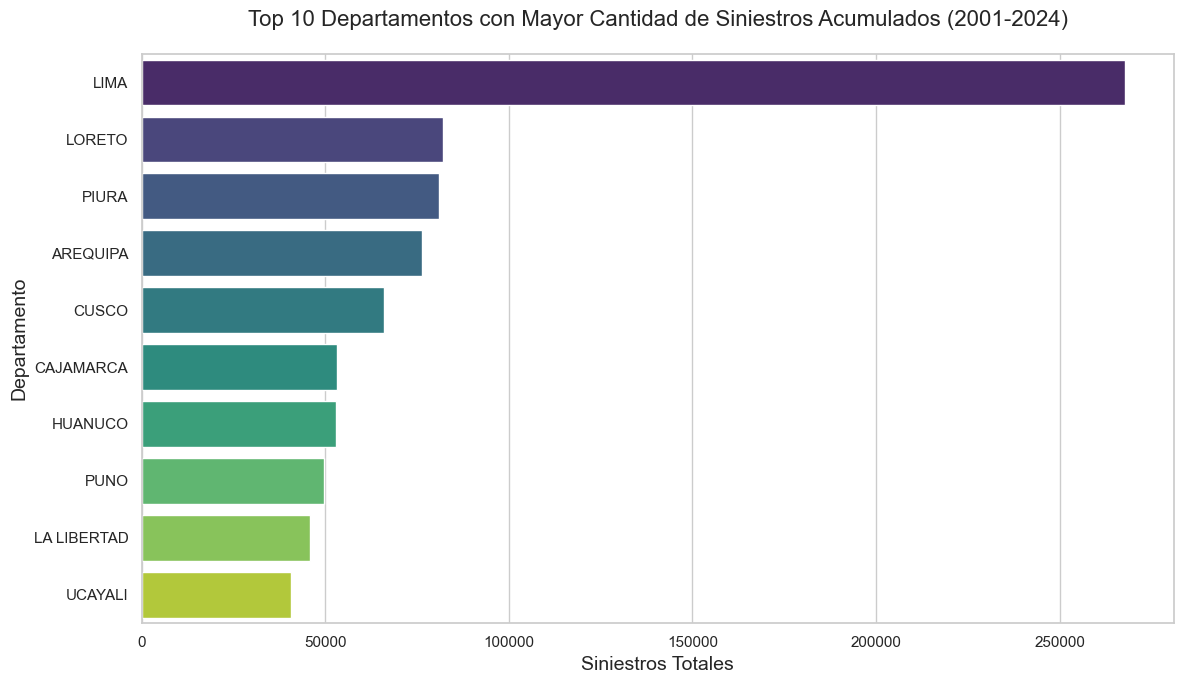

In [2]:
# Agrupación por departamento de los siniestros totales (smb + enterprise)
df_geo = df.groupBy("departamento") \
    .agg(sum(col("siniestros_smb") + col("siniestros_enterprise")).alias("total_siniestros")) \
    .orderBy(col("total_siniestros").desc())

# Convertir a Pandas para graficar con Seaborn de forma estética
pdf_geo = df_geo.limit(10).toPandas()

plt.figure(figsize=(12, 7))
sns.barplot(data=pdf_geo, x="total_siniestros", y="departamento", palette="viridis")
plt.title("Top 10 Departamentos con Mayor Cantidad de Siniestros Acumulados (2001-2024)", pad=20)
plt.xlabel("Siniestros Totales")
plt.ylabel("Departamento")
plt.tight_layout()
plt.show()

### 2.2. Correlación Pearson: Pólizas Nuevas vs. Siniestros Totales

Calculamos la correlación para entender la relación lineal básica entre la colocación de nuevas pólizas y la ocurrencia de siniestros.

In [3]:
from pyspark.ml.stat import Correlation

# Agrupamos datos semanales a nivel país para correlacionar
df_corr_data = df.groupBy("anio", "semana") \
    .agg(
        sum("polizas_nuevas").alias("total_polizas"),
        sum(col("siniestros_smb") + col("siniestros_enterprise")).alias("total_siniestros")
    )

assembler_corr = VectorAssembler(inputCols=["total_polizas", "total_siniestros"], outputCol="features")
df_vector_corr = assembler_corr.transform(df_corr_data).select("features")

matrix = Correlation.corr(df_vector_corr, "features").head()
correlation_value = matrix[0].toArray()[0, 1]

print(f"Matriz de Correlación de Pearson:\n{matrix[0]}")
print(f"\nCoeficiente de correlación entre pólizas nuevas y siniestros: {correlation_value:.4f}")

Matriz de Correlación de Pearson:
DenseMatrix([[1.        , 0.38484309],
             [0.38484309, 1.        ]])

Coeficiente de correlación entre pólizas nuevas y siniestros: 0.3848


## 3. Ingeniería de Características

Para evitar fugas de información, agrupamos los siniestros cronológicamente y generamos variables basadas únicamente en el pasado (`lag_1`, `lag_2` y una media móvil de 3 semanas `rolling_mean_3`). Esto evita que el modelo use datos futuros.

In [4]:
# Agrupación cronológica nacional
df_semanal = df.groupBy("anio", "semana") \
    .agg(sum(col("siniestros_smb") + col("siniestros_enterprise")).alias("siniestros_esta_semana")) \
    .orderBy("anio", "semana")

window_spec = Window.orderBy("anio", "semana")

# Ingeniería de características robusta utilizando solo datos históricos pasados
df_features = df_semanal \
    .withColumn("lag_1", lag("siniestros_esta_semana", 1).over(window_spec)) \
    .withColumn("lag_2", lag("siniestros_esta_semana", 2).over(window_spec)) \
    .withColumn("rolling_mean_3", (lag("siniestros_esta_semana", 1).over(window_spec) + 
                                  lag("siniestros_esta_semana", 2).over(window_spec) + 
                                  lag("siniestros_esta_semana", 3).over(window_spec)) / 3) \
    .na.drop()  # Removemos las primeras filas con nulos debido a los lags

df_features.show(10, truncate=False)

+----+------+----------------------+-----+-----+------------------+
|anio|semana|siniestros_esta_semana|lag_1|lag_2|rolling_mean_3    |
+----+------+----------------------+-----+-----+------------------+
|2001|4     |1038                  |1195 |1329 |1223.3333333333333|
|2001|5     |1034                  |1038 |1195 |1187.3333333333333|
|2001|6     |1007                  |1034 |1038 |1089.0            |
|2001|7     |1045                  |1007 |1034 |1026.3333333333333|
|2001|8     |1083                  |1045 |1007 |1028.6666666666667|
|2001|9     |954                   |1083 |1045 |1045.0            |
|2001|10    |1076                  |954  |1083 |1027.3333333333333|
|2001|11    |1189                  |1076 |954  |1037.6666666666667|
|2001|12    |1254                  |1189 |1076 |1073.0            |
|2001|13    |1094                  |1254 |1189 |1173.0            |
+----+------+----------------------+-----+-----+------------------+
only showing top 10 rows


## 4. División Temporal Cronológica (Eliminación de Data Leakage)

Dividimos los datos en base a un año de corte específico para simular un escenario predictivo real. 
- **Entrenamiento**: Datos desde 2001 hasta el 2019.
- **Test**: Datos desde el 2020 hasta el 2024 (periodo ideal para evaluar robustez ante cambios estructurales como el COVID-19).

In [5]:
# Ensamblamos las variables en la columna 'features'
feature_cols = ["lag_1", "lag_2", "rolling_mean_3"]
assembler_reg = VectorAssembler(inputCols=feature_cols, outputCol="features")
df_final = assembler_reg.transform(df_features).withColumnRenamed("siniestros_esta_semana", "label")

# División temporal en vez de split aleatorio
df_train = df_final.filter(col("anio") < 2020)
df_test = df_final.filter(col("anio") >= 2020)

print(f"Número de observaciones en Entrenamiento (2001-2019): {df_train.count()}")
print(f"Número de observaciones en Test (2020-2024): {df_test.count()}")

Número de observaciones en Entrenamiento (2001-2019): 985


Número de observaciones en Test (2020-2024): 260


## 5. Modelado y Evaluación Generalizable con GBT Regressor

Entrenamos el modelo de Gradient-Boosted Trees (GBT) en el set de entrenamiento y lo evaluamos en ambos conjuntos para diagnosticar posibles problemas de overfitting.

In [6]:
# Inicializar y entrenar el modelo GBT Regressor
gbt = GBTRegressor(featuresCol="features", labelCol="label", seed=42)
model_gbt = gbt.fit(df_train)

# Generar predicciones en train y test
predictions_train = model_gbt.transform(df_train)
predictions_test = model_gbt.transform(df_test)

# Evaluadores para métricas de regresión
eval_rmse = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="rmse")
eval_mae = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="mae")
eval_r2 = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="r2")

# Calcular métricas
rmse_train = eval_rmse.evaluate(predictions_train)
mae_train = eval_mae.evaluate(predictions_train)
r2_train = eval_r2.evaluate(predictions_train)

rmse_test = eval_rmse.evaluate(predictions_test)
mae_test = eval_mae.evaluate(predictions_test)
r2_test = eval_r2.evaluate(predictions_test)

print("\n--- MÉTRICAS DE ENTRENAMIENTO (2001-2019) ---")
print(f"RMSE: {rmse_train:.2f}")
print(f"MAE:  {mae_train:.2f}")
print(f"R2:   {r2_train:.4f}")

print("\n--- MÉTRICAS DE TEST (2020-2024) ---")
print(f"RMSE: {rmse_test:.2f}")
print(f"MAE:  {mae_test:.2f}")
print(f"R2:   {r2_test:.4f}")


--- MÉTRICAS DE ENTRENAMIENTO (2001-2019) ---
RMSE: 88.63
MAE:  62.84
R2:   0.9133

--- MÉTRICAS DE TEST (2020-2024) ---
RMSE: 110.98
MAE:  80.63
R2:   0.8685


### 5.2. Visualización Evolutiva: Real vs. Predicho (Periodo de Test)

Graficamos la evolución temporal en el conjunto de test para comprobar visualmente la calidad de la predicción ante el comportamiento real.

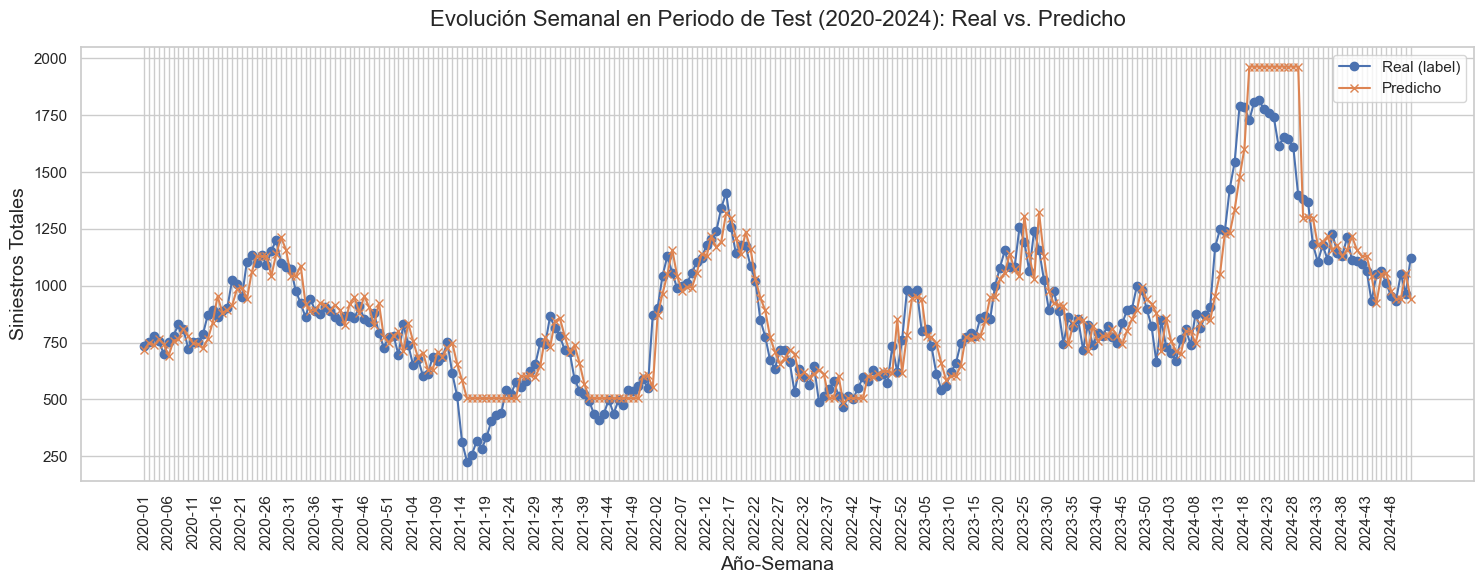

In [7]:
# Guardamos predicciones de test en CSV para Streamlit u otros usos
preds_test_df = predictions_test \
    .select("anio", "semana", "label", "prediction") \
    .withColumn("year_week", format_string("%d-%02d", col("anio"), col("semana"))) \
    .orderBy("anio", "semana") \
    .toPandas()

preds_test_df.to_csv("predicciones_regresion.csv", index=False)

# Graficar
plt.figure(figsize=(15, 6))
plt.plot(preds_test_df["year_week"], preds_test_df["label"], marker='o', label="Real (label)", linewidth=1.5)
plt.plot(preds_test_df["year_week"], preds_test_df["prediction"], marker='x', label="Predicho", linewidth=1.5)
plt.title("Evolución Semanal en Periodo de Test (2020-2024): Real vs. Predicho", pad=15)
plt.xlabel("Año-Semana")
plt.ylabel("Siniestros Totales")
plt.xticks(rotation=90)

# Reducir marcas en el eje X para mejorar legibilidad
ax = plt.gca()
for index, label in enumerate(ax.xaxis.get_ticklabels()):
    if index % 5 != 0:
        label.set_visible(False)

plt.legend(frameon=True)
plt.tight_layout()
plt.show()

## 6. Segmentación Departamental

Primero agrupamos todas las métricas operativas por departamento y normalizamos las características.

In [8]:
# Agrupación por departamento de todas las métricas clave
df_perfil_depto = df.groupBy("departamento") \
    .agg(
        sum(col("siniestros_smb") + col("siniestros_enterprise")).alias("siniestros_totales"),
        sum(col("reclamos_smb") + col("reclamos_enterprise")).alias("total_reclamos"),
        sum(col("bajas_poliza_smb") + col("bajas_poliza_enterprise")).alias("total_bajas"),
        sum("polizas_nuevas").alias("polizas_nuevas_totales")
    )

# Ensamblar características y escalar
feature_cols_cluster = ["siniestros_totales", "total_reclamos", "total_bajas", "polizas_nuevas_totales"]
assembler_cluster = VectorAssembler(inputCols=feature_cols_cluster, outputCol="features_raw")
df_vector_cluster = assembler_cluster.transform(df_perfil_depto)

scaler = StandardScaler(inputCol="features_raw", outputCol="features", withStd=True, withMean=True)
scaler_model = scaler.fit(df_vector_cluster)
df_scaled = scaler_model.transform(df_vector_cluster)

### 6.2. Método del Codo (Elbow Method) para Justificar K

Calculamos la inercia (WSSSE / training cost) evaluando K de 2 a 7 para encontrar el punto de inflexión óptimo.

Evaluando K-Means para K de 2 a 7...


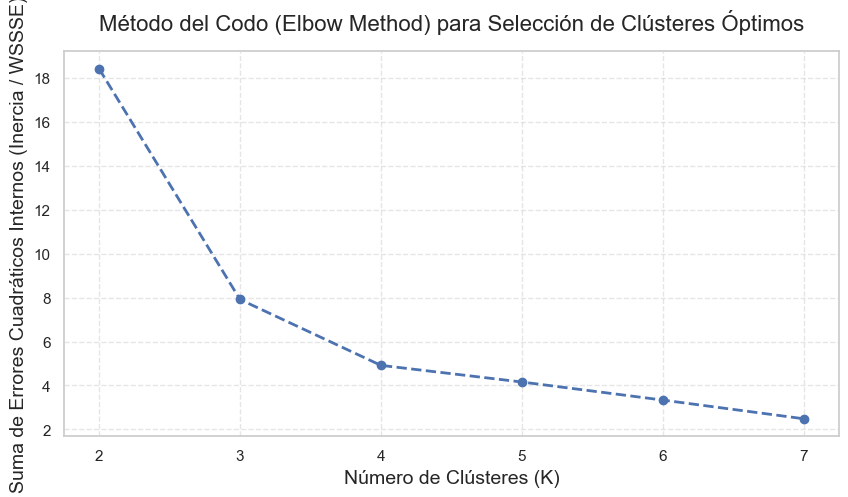

K = 2 -> Costo de entrenamiento (Inercia): 18.4051
K = 3 -> Costo de entrenamiento (Inercia): 7.9108
K = 4 -> Costo de entrenamiento (Inercia): 4.9149
K = 5 -> Costo de entrenamiento (Inercia): 4.1577
K = 6 -> Costo de entrenamiento (Inercia): 3.3365
K = 7 -> Costo de entrenamiento (Inercia): 2.4866


In [9]:
wssse_list = []
print("Evaluando K-Means para K de 2 a 7...")

for k in range(2, 8):
    kmeans = KMeans(featuresCol="features", k=k, seed=42)
    model = kmeans.fit(df_scaled)
    wssse_list.append((k, model.summary.trainingCost))

# Graficar el Método del Codo
k_vals = [x[0] for x in wssse_list]
wssse_vals = [x[1] for x in wssse_list]

plt.figure(figsize=(10, 5))
plt.plot(k_vals, wssse_vals, marker='o', linestyle='--', color='b', linewidth=2)
plt.title("Método del Codo (Elbow Method) para Selección de Clústeres Óptimos", pad=15)
plt.xlabel("Número de Clústeres (K)")
plt.ylabel("Suma de Errores Cuadráticos Internos (Inercia / WSSSE)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

for k, cost in wssse_list:
    print(f"K = {k} -> Costo de entrenamiento (Inercia): {cost:.4f}")

### 6.3. Entrenamiento del Modelo K-Means con K Óptimo

A partir del gráfico del codo, seleccionamos el valor de K óptimo y entrenamos el modelo final.

In [10]:
# En base al análisis del codo, K=3 o K=4 son los puntos óptimos. Usaremos K=3 para máxima interpretabilidad
k_optimo = 3
print(f"Entrenando K-Means con K óptimo = {k_optimo}...")

kmeans_final = KMeans(featuresCol="features", k=k_optimo, seed=42)
model_kmeans = kmeans_final.fit(df_scaled)
predictions_cluster = model_kmeans.transform(df_scaled)

# Guardamos resultados agregados para Streamlit
predictions_cluster \
    .select("departamento", "siniestros_totales", "total_reclamos", "total_bajas", "polizas_nuevas_totales", "prediction") \
    .toPandas() \
    .to_csv('resultados_cluster.csv', index=False)

print("\nResultados del Clustering por Departamento:")
predictions_cluster.select("departamento", "prediction").orderBy("prediction").show(30)

Entrenando K-Means con K óptimo = 3...



Resultados del Clustering por Departamento:


+-------------+----------+
| departamento|prediction|
+-------------+----------+
|     AMAZONAS|         0|
|       ANCASH|         0|
|     APURIMAC|         0|
|     AYACUCHO|         0|
|       CALLAO|         0|
| HUANCAVELICA|         0|
|          ICA|         0|
|   LAMBAYEQUE|         0|
|        PASCO|         0|
|MADRE DE DIOS|         0|
|     MOQUEGUA|         0|
|   SAN MARTIN|         0|
|       TUMBES|         0|
|        TACNA|         0|
|      UCAYALI|         0|
|         LIMA|         1|
|     AREQUIPA|         2|
|    CAJAMARCA|         2|
|        CUSCO|         2|
|      HUANUCO|         2|
|        JUNIN|         2|
|  LA LIBERTAD|         2|
|       LORETO|         2|
|        PIURA|         2|
|         PUNO|         2|
+-------------+----------+



### 6.4. Proyección 2D PCA y Visualización

Proyectamos las características a un espacio bidimensional (PCA) para visualizar los departamentos y sus clústeres en 2D.

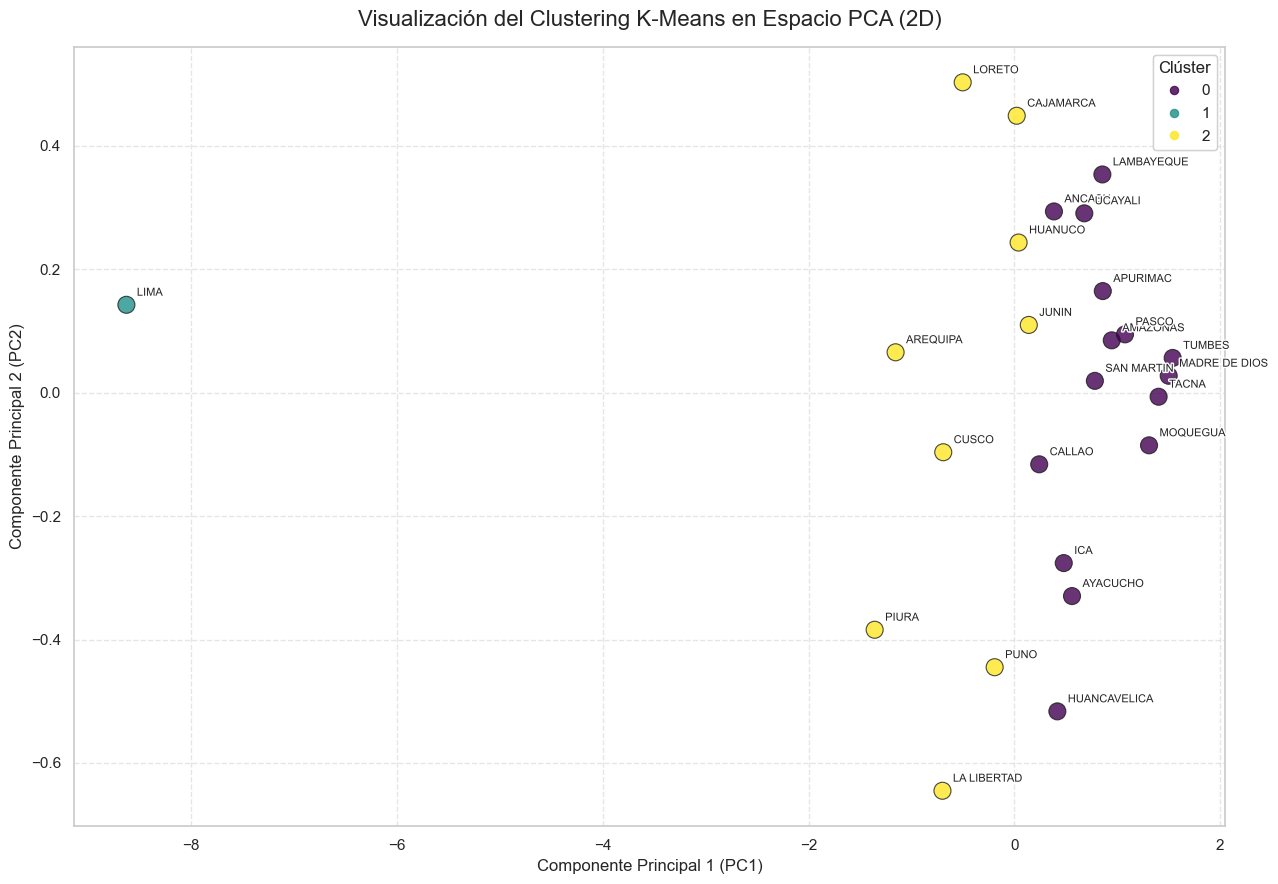

In [11]:
# Ajustar PCA sobre las mismas características escaladas
pca = PCAml(k=2, inputCol="features", outputCol="pca2")
pca_model = pca.fit(df_scaled)
pred_pca = pca_model.transform(predictions_cluster)

# Seleccionar columnas y exportar
pdf = pred_pca.select("departamento", "prediction", "pca2").toPandas()
pc_df = pd.DataFrame(pdf["pca2"].tolist(), columns=["pc1", "pc2"])
pdf = pd.concat([pdf.drop(columns=["pca2"]), pc_df], axis=1)
pdf.to_csv("resultados_cluster_pca.csv", index=False)

# Graficar con etiquetas de TODOS los departamentos
plt.figure(figsize=(13, 9))
scatter = plt.scatter(
    pdf["pc1"], pdf["pc2"],
    c=pdf["prediction"],
    cmap="viridis",
    s=150,
    alpha=0.8,
    edgecolors='k',
    linewidth=0.8
)

plt.title("Visualización del Clustering K-Means en Espacio PCA (2D)", fontsize=16, pad=15)
plt.xlabel("Componente Principal 1 (PC1)", fontsize=12)
plt.ylabel("Componente Principal 2 (PC2)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)

# Leyenda de clústeres
legend1 = plt.legend(*scatter.legend_elements(), title="Clúster")
plt.gca().add_artist(legend1)

# Etiquetar todos los departamentos sin solapamiento severo usando un pequeño offset
dx = 0.01 * (pdf["pc1"].max() - pdf["pc1"].min())
dy = 0.01 * (pdf["pc2"].max() - pdf["pc2"].min())

for _, row in pdf.iterrows():
    plt.text(
        row["pc1"] + dx,
        row["pc2"] + dy,
        row["departamento"],
        fontsize=8,
        ha="left",
        va="bottom",
        path_effects=[pe.withStroke(linewidth=2, foreground="white")]
    )

plt.tight_layout()
plt.show()

## 7. Cierre de la Sesión Spark

Detenemos la sesión Spark para liberar los recursos locales.

In [12]:
spark.stop()
print("\n¡Sesión Spark cerrada con éxito!")


¡Sesión Spark cerrada con éxito!
